In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import json
import sqlite3
import bisect
import math

In [2]:
def stream_results(filename):
    with open(filename, 'rb') as f:
        while True:
            try:
                # Reads the next object from the stream
                yield pickle.load(f)
            except EOFError:
                # We reached the end of the file
                break

In [5]:
file = "results/utm15_2_results_len30.pkl"
max_runtime = 100_000
utm_num_runtimes = np.zeros(max_runtime, dtype=int)
utm_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

with open(file, "rb") as f:
    counter = 0
    while True:
        try:
            batch = pickle.load(f)
            for length, steps in batch:
                utm_num_runtimes[steps] += 1
                utm_num_runtimes_weighted[steps] += 2.0 ** (-length - 2*np.log2(length) - 2)
                if counter % 1_000_000 == 0:
                    print(f"Processed {counter} results, most common runtime: {np.argmax(utm_num_runtimes[:1000])} with {max(utm_num_runtimes[:1000])} programs")
                counter += 1
        except EOFError:
            break

Processed 0 results, most common runtime: 33 with 1 programs
Processed 1000000 results, most common runtime: 8 with 230303 programs
Processed 2000000 results, most common runtime: 8 with 449337 programs
Processed 3000000 results, most common runtime: 8 with 663773 programs
Processed 4000000 results, most common runtime: 8 with 878059 programs
Processed 5000000 results, most common runtime: 8 with 1076442 programs
Processed 6000000 results, most common runtime: 8 with 1287374 programs
Processed 7000000 results, most common runtime: 8 with 1493645 programs
Processed 8000000 results, most common runtime: 8 with 1706606 programs
Processed 9000000 results, most common runtime: 8 with 1893583 programs
Processed 10000000 results, most common runtime: 8 with 2089318 programs
Processed 11000000 results, most common runtime: 8 with 2306125 programs
Processed 12000000 results, most common runtime: 8 with 2511540 programs
Processed 13000000 results, most common runtime: 8 with 2722022 programs
Pro

In [2]:
# save the num runtimes arrays to a file
with open("results/utm15_2_num_runtimes.pkl", "wb") as f:
    pickle.dump(utm_num_runtimes, f)

with open("results/utm15_2_num_runtimes_weighted.pkl", "wb") as f:
    pickle.dump(utm_num_runtimes_weighted, f)

NameError: name 'utm_num_runtimes' is not defined

In [7]:
file = "results/bf_results_len11.pkl"
bf_num_runtimes = np.zeros(max_runtime, dtype=int)
bf_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    length = len(result["program"])
    weight = 8 ** (-length + 1)
    bf_num_runtimes[steps] += 1
    bf_num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(bf_num_runtimes[:1000])} with {max(bf_num_runtimes[:1000])} programs")

Processed 1000000 results, most common runtime: 9 with 322294 programs
Processed 2000000 results, most common runtime: 9 with 733867 programs
Processed 3000000 results, most common runtime: 9 with 925725 programs
Processed 4000000 results, most common runtime: 9 with 996470 programs
Processed 5000000 results, most common runtime: 10 with 1187862 programs
Processed 6000000 results, most common runtime: 10 with 1693327 programs
Processed 7000000 results, most common runtime: 10 with 2309476 programs
Processed 8000000 results, most common runtime: 10 with 2942297 programs
Processed 9000000 results, most common runtime: 10 with 3391016 programs
Processed 10000000 results, most common runtime: 10 with 3488850 programs
Processed 11000000 results, most common runtime: 10 with 3712292 programs
Processed 12000000 results, most common runtime: 10 with 3712567 programs
Processed 13000000 results, most common runtime: 10 with 3712803 programs
Processed 14000000 results, most common runtime: 10 wit

In [3]:
# save the num runtimes arrays to a file
with open("results/bf_num_runtimes.pkl", "wb") as f:
    pickle.dump(bf_num_runtimes, f)

with open("results/bf_num_runtimes_weighted.pkl", "wb") as f:
    pickle.dump(bf_num_runtimes_weighted, f)

NameError: name 'bf_num_runtimes' is not defined

In [4]:
file = "results/tag_results_len13.pkl"
max_runtime = 100_000
tag_num_runtimes = np.zeros(max_runtime, dtype=int)
tag_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# Precompute cumulative counts and weights for O(1) lookup
lengths = list(range(3, 25))
partitions = [(l - 1) * (l - 2) // 2 for l in lengths]
counts = [(3 ** (l + 1)) * p for l, p in zip(lengths, partitions)]
cum_counts = list(np.cumsum(counts))

# Weighting by total rule length (4-character alphabet: 'a','b','c','H')
weights_lookup = [4 ** (-(l + 3)) for l in lengths]

counter = 0
for result in stream_results(file):
    counter += 1
    program_index, steps = result
    
    # Reconstruct length and weight
    len_idx = bisect.bisect_right(cum_counts, program_index)
    weight = weights_lookup[len_idx]
    
    tag_num_runtimes[steps] += 1
    tag_num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter:,} results, most common runtime: {np.argmax(tag_num_runtimes[:1000])} with {max(tag_num_runtimes[:1000])} programs")


Processed 1,000,000 results, most common runtime: 2 with 311426 programs
Processed 2,000,000 results, most common runtime: 2 with 595906 programs
Processed 3,000,000 results, most common runtime: 2 with 861364 programs
Processed 4,000,000 results, most common runtime: 2 with 1106540 programs
Processed 5,000,000 results, most common runtime: 2 with 1358471 programs
Processed 6,000,000 results, most common runtime: 2 with 1603372 programs
Processed 7,000,000 results, most common runtime: 2 with 1847054 programs
Processed 8,000,000 results, most common runtime: 2 with 2106833 programs
Processed 9,000,000 results, most common runtime: 2 with 2364012 programs
Processed 10,000,000 results, most common runtime: 2 with 2601841 programs
Processed 11,000,000 results, most common runtime: 2 with 2815655 programs
Processed 12,000,000 results, most common runtime: 2 with 3026252 programs
Processed 13,000,000 results, most common runtime: 2 with 3237938 programs
Processed 14,000,000 results, most co

In [5]:
# save the num runtimes arrays to a file
with open("results/tag_num_runtimes.pkl", "wb") as f:
    pickle.dump(tag_num_runtimes, f)

with open("results/tag_num_runtimes_weighted.pkl", "wb") as f:
    pickle.dump(tag_num_runtimes_weighted, f)

In [9]:
file = "results/rule110_results_len24.pkl"
rule110_num_runtimes = np.zeros(max_runtime, dtype=int)
rule110_num_runtimes_weighted = np.zeros(max_runtime, dtype=float)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    length = len(result["program"])
    weight = 2 ** (-length - 2*np.log2(length) - 2)
    rule110_num_runtimes[steps] += 1
    rule110_num_runtimes_weighted[steps] += weight

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(rule110_num_runtimes[:1000])} with {max(rule110_num_runtimes[:1000])} programs")

Processed 1000000 results, most common runtime: 140 with 14368 programs
Processed 2000000 results, most common runtime: 133 with 26744 programs
Processed 3000000 results, most common runtime: 133 with 37124 programs
Processed 4000000 results, most common runtime: 133 with 45431 programs
Processed 5000000 results, most common runtime: 49 with 59205 programs
Processed 6000000 results, most common runtime: 133 with 66038 programs
Processed 7000000 results, most common runtime: 133 with 75216 programs
Processed 8000000 results, most common runtime: 133 with 85400 programs
Processed 9000000 results, most common runtime: 140 with 97731 programs
Processed 10000000 results, most common runtime: 140 with 109671 programs
Processed 11000000 results, most common runtime: 140 with 121464 programs
Processed 12000000 results, most common runtime: 140 with 135085 programs
Processed 13000000 results, most common runtime: 140 with 146856 programs
Processed 14000000 results, most common runtime: 140 with

In [12]:
# save the num runtimes arrays to a file
with open("results/rule110_num_runtimes.pkl", "wb") as f:
    pickle.dump(rule110_num_runtimes, f)

with open("results/rule110_num_runtimes_weighted.pkl", "wb") as f:
    pickle.dump(rule110_num_runtimes_weighted, f)

# Load Pre-Processed Files

In [52]:
# save weighted num_runtimes as .csv files, with two columns: runtime, probability
# create a function to save the weighted num_runtimes as .csv files
def save_weighted_num_runtimes_to_csv(num_runtimes_weighted, filename):
    total_programs = np.sum(num_runtimes_weighted)
    probabilities = num_runtimes_weighted / total_programs
    with open(filename, "w") as f:
        f.write("runtime,probability\n")
        for i in range(len(probabilities)):
            if probabilities[i] > 0.:
                f.write(f"{i},{probabilities[i]}\n")

# save the weighted num_runtimes as .csv files
save_weighted_num_runtimes_to_csv(utm_num_runtimes_weighted, "results/utm15_2_num_runtimes_weighted.csv")
save_weighted_num_runtimes_to_csv(bf_num_runtimes_weighted, "results/bf_num_runtimes_weighted.csv")
save_weighted_num_runtimes_to_csv(tag_num_runtimes_weighted, "results/tag_num_runtimes_weighted.csv")
save_weighted_num_runtimes_to_csv(rule110_num_runtimes_weighted, "results/rule110_num_runtimes_weighted.csv")

In [ ]:
# load all num_runtimes from the files
with open("results/utm15_2_num_runtimes_weighted.pkl", "rb") as f:
    utm_num_runtimes_weighted = pickle.load(f)

#with open("results/bf_num_runtimes.pkl", "rb") as f:
#    bf_num_runtimes = pickle.load(f)

with open("results/bf_num_runtimes_weighted.pkl", "rb") as f:
    bf_num_runtimes_weighted = pickle.load(f)

#with open("results/tag_num_runtimes.pkl", "rb") as f:
#    tag_num_runtimes = pickle.load(f)

with open("results/tag_num_runtimes_weighted.pkl", "rb") as f:
    tag_num_runtimes_weighted = pickle.load(f)

#with open("results/rule110_num_runtimes.pkl", "rb") as f:
#    rule110_num_runtimes = pickle.load(f)

with open("results/rule110_num_runtimes_weighted.pkl", "rb") as f:
    rule110_num_runtimes_weighted = pickle.load(f)



In [3]:
# log-log plot of runtimes against probability
utm_total_programs = np.sum(utm_num_runtimes)
utm_probabilities = utm_num_runtimes / utm_total_programs

bf_total_programs = np.sum(bf_num_runtimes)
bf_probabilities = bf_num_runtimes / bf_total_programs

tag_total_programs = np.sum(tag_num_runtimes)
tag_probabilities = tag_num_runtimes / tag_total_programs

rule110_total_programs = np.sum(rule110_num_runtimes)
rule110_probabilities = rule110_num_runtimes / rule110_total_programs

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), tag_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Tag System")
plt.loglog(np.arange(max_runtime), bf_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="BF")
plt.loglog(np.arange(max_runtime), utm_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")
plt.loglog(np.arange(max_runtime), rule110_probabilities, marker='o', linestyle='None', markersize=3, alpha=0.7, label="Rule 110")

reference_curve = 1 / np.arange(1, max_runtime)
plt.loglog(np.arange(1, max_runtime), reference_curve, color='grey', linestyle='--', label='Reference Curve: $1/t$')
plt.legend()

plt.title('Runtime vs Probability (uniform)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

NameError: name 'utm_num_runtimes' is not defined

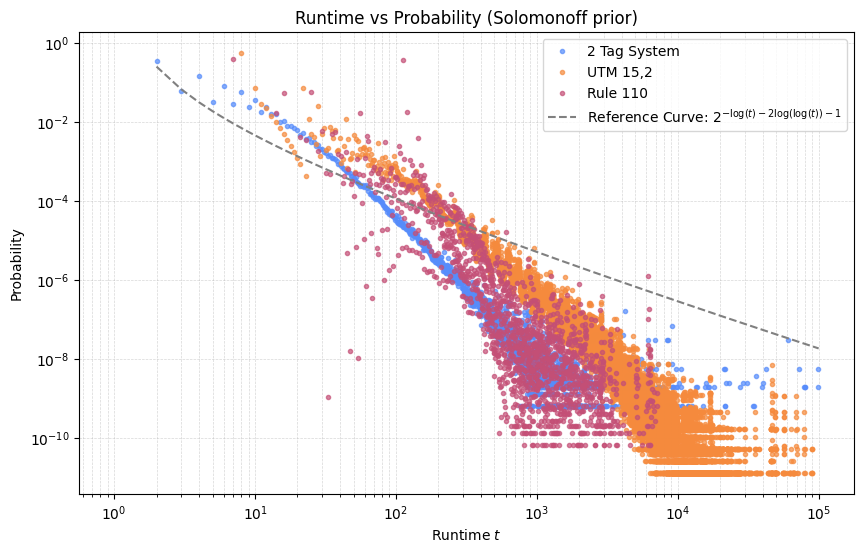

In [48]:
max_runtime = 100_000

# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

bf_total_programs_weighted = np.sum(bf_num_runtimes_weighted)
bf_probabilities_weighted = bf_num_runtimes_weighted / bf_total_programs_weighted

tag_total_programs_weighted = np.sum(tag_num_runtimes_weighted)
tag_probabilities_weighted = tag_num_runtimes_weighted / tag_total_programs_weighted

rule110_total_programs_weighted = np.sum(rule110_num_runtimes_weighted)
rule110_probabilities_weighted = rule110_num_runtimes_weighted / rule110_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), tag_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Tag System")
#plt.loglog(np.arange(max_runtime), bf_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="BF")
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")
plt.loglog(np.arange(max_runtime), rule110_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="Rule 110")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
reference_curve = 2 ** (-np.log2(x_range[1:]) - 2*np.log2(np.log2(x_range[1:])) - 1)
plt.loglog(x_range[1:], reference_curve, color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 1}$')
plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)


# save plot as pdf
plt.savefig("runtime_vs_probability.pdf")

plt.show()

In [ ]:
# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
reference_curve = 2 ** (-np.log2(x_range[1:]) - 2*np.log2(np.log2(x_range[1:])) - 2)
plt.loglog(x_range[1:], reference_curve, color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 2}$')
plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [6]:
def binary_representation(n, encoding_level=1):
    """Return the binary representation of an integer n as a boolean array of bits."""
    if n == 0:
        return np.array([False])
    bits = []

    current_level = 1
    current_n = n
    while current_level <= encoding_level:
        current_bits = []
        while current_n:
            current_bits.append(bool(current_n & 1))
            current_n >>= 1
        if current_level == encoding_level:
            bits = [b for b in current_bits[::-1] for _ in range(2)] + [0] + bits
            break
        else:
            bits = current_bits[::-1] + bits
            current_n = len(current_bits)
            current_level += 1

    return np.array(bits, dtype=bool)

In [7]:
binary_representation(1024, encoding_level=2).astype(int)

array([1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [8]:
def description_length(n):
    p_one = np.mean(n)
    description_length = 0
    for bit in n:
        if bit:
            description_length += -np.log2(p_one) if p_one > 0 else 0
        else:
            description_length += -np.log2(1 - p_one) if p_one < 1 else 0

    return description_length


def lz76_kolmogorov_estimate(n: np.ndarray) -> dict:
    """
    Estimates the Kolmogorov complexity (in bits) of a 1D boolean array
    by tracking the exact history pointers and innovation bits.
    """
    length = len(n)
    if length == 0:
        return {"phrases": 0, "bits_exact": 0, "bits_asymptotic": 0.0, "normalized_complexity": 0.0}

    b = n.astype(np.uint8).tobytes()

    phrases = 1
    start = 0
    end = 1
    total_bits = 1  # First bit is explicit

    while end <= length:
        sub = b[start:end]
        history = b[0:end - 1]

        match_idx = history.find(sub)

        if match_idx != -1 and end < length:
            end += 1
        else:
            phrases += 1
            # Pointer to history location: log2(history length) + 1 bit for the new symbol
            if start > 0:
                pointer_bits = math.ceil(math.log2(start + 1))
                total_bits += pointer_bits + 1  # pointer + next bit
            else:
                total_bits += 1

            start = end
            end = start + 1

    # Theoretical asymptotic estimate: c(n) * log2(n)
    asymptotic_bits = phrases * (math.log2(length) if length > 1 else 1)

    # Normalized complexity against a random string: c(n) / (n / log2(n))
    random_bound = length / math.log2(length) if length > 1 else 1
    normalized_complexity = min(1.0, phrases / random_bound)

    return {
        "phrases": phrases,
        "bits_exact": total_bits,
        "bits_asymptotic": asymptotic_bits,
        "normalized_complexity": normalized_complexity
    }

In [9]:
description_length(binary_representation(2048, 2))

16.629025403917147

In [10]:
br1 = [binary_representation(i, 1) for i in x_range]
br2 = [binary_representation(i, 2) for i in x_range]
br3 = [binary_representation(i, 3) for i in x_range]

length_l1 = np.array([float(len(b)) for b in br1])
length_l2 = np.array([float(len(b)) for b in br2])
length_l3 = np.array([float(len(b)) for b in br3])

description_lengths_l1 = np.array([description_length(b) for b in br1])
description_lengths_l2 = np.array([description_length(b) for b in br2])
description_lengths_l3 = np.array([description_length(b) for b in br3])

lz_lengths_l1 = np.array([float(lz76_kolmogorov_estimate(b)["bits_exact"]) for b in br1])
lz_lengths_l2 = np.array([float(lz76_kolmogorov_estimate(b)["bits_exact"]) for b in br2])
lz_lengths_l3 = np.array([float(lz76_kolmogorov_estimate(b)["bits_exact"]) for b in br3])

In [118]:
def compute_dsl_lengths(
    limit: int = 100_000,
    c_double: int = 1,
    c_add_sub: int = 3,
    c_halt: int = 2,
) -> list[int]:
    """Computes the minimal DSL prefix-free description length (in bits)

    for all integers from 1 to limit (inclusive).

    Returns a 1-indexed list of length (limit + 1), where result[n] is the
    description length in bits for integer n. Index 0 is set to 0.
    """
    # cost_ops[n] stores the operational cost from 1 to n (excluding HALT)
    cost_ops = [0] * (limit + 1)
    cost_ops[1] = 0

    c_odd_step = c_double + c_add_sub  # 1 + 3 = 4

    for i in range(2, limit + 1):
        if i % 2 == 0:
            cost_ops[i] = cost_ops[i >> 1] + c_double
        else:
            k = i >> 1
            # i = 2k + 1: transition is either *2, +1 from k, or *2, -1 from k + 1
            cost_ops[i] = c_odd_step + (
                cost_ops[k] if cost_ops[k] < cost_ops[k + 1] else cost_ops[k + 1]
            )

    # Add HALT code length to obtain complete prefix-free codeword lengths
    return [cost + c_halt if i >= 1 else 0 for i, cost in enumerate(cost_ops)]


# --- Execution and Verification ---
dsl_lengths = compute_dsl_lengths(100_000)

# Sanity checks
assert dsl_lengths[1] == 2  # HALT only
assert dsl_lengths[3] == 6  # *2 +1 HALT
assert dsl_lengths[11] == 11  # *2 *2 +1 *2 +1 HALT
assert dsl_lengths[255] == 13  # (*2)^8 -1 HALT
assert dsl_lengths[65535] == 21  # (*2)^16 -1 HALT

print(f"Computed {len(dsl_lengths) - 1:,} values.")
print(f"Sample - n=100,000: {dsl_lengths[100_000]} bits")
print(f"Average length (1 to 100,000): {sum(dsl_lengths[1:]) / 100_000:.2f} bits")
print(f"Maximum length (1 to 100,000): {max(dsl_lengths)} bits")

Computed 100,000 values.
Sample - n=100,000: 33 bits
Average length (1 to 100,000): 31.91 bits
Maximum length (1 to 100,000): 42 bits


In [124]:
len(dsl_lengths)

100001

/tmp/ipykernel_2215853/3804923732.py:6: RuntimeWarning: divide by zero encountered in log2
  plt.plot(x_range, [np.log2(r) + 2*np.log2(np.log2(r)) + 1 for r in x_range], label="Binary Representation Lengths (Level 2), continuous")


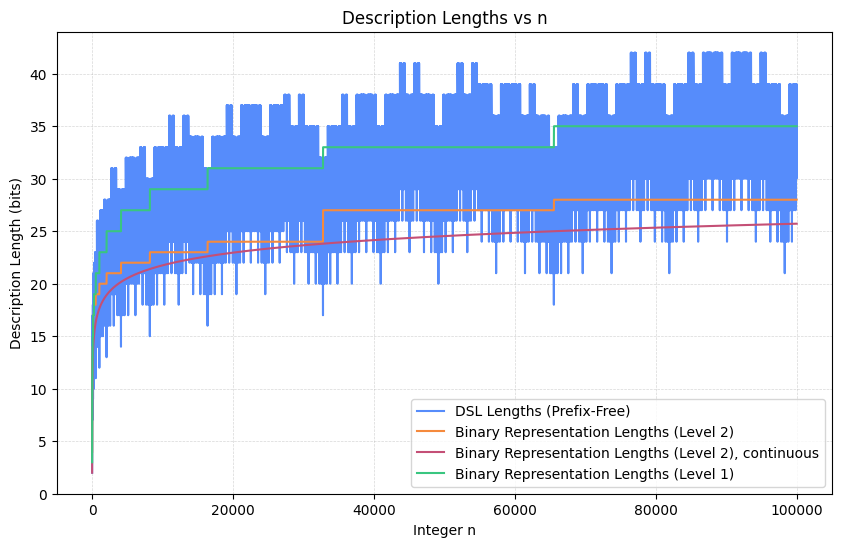

In [159]:
# plot the DSL lengths and length_l2 against n

plt.figure(figsize=(10, 6))
plt.plot(x_range, dsl_lengths[1:-1], label="DSL Lengths (Prefix-Free)")
plt.plot(x_range, length_l2, label="Binary Representation Lengths (Level 2)")
plt.plot(x_range, [np.log2(r) + 2*np.log2(np.log2(r)) + 1 for r in x_range], label="Binary Representation Lengths (Level 2), continuous")
plt.plot(x_range, length_l1, label="Binary Representation Lengths (Level 1)")
plt.title("Description Lengths vs n")
plt.xlabel("Integer n")
plt.ylabel("Description Length (bits)")
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

# Measure Correlation

In [160]:
import pandas as pd
import seaborn as sns
from pingouin import partial_corr

In [177]:
# dictionary from runtime_probs
runtime_probs = {
    "tag": tag_probabilities_weighted,
    "utm": utm_probabilities_weighted,
    "rule110": rule110_probabilities_weighted,
}

# dictionary from runtime description lengths
runtime_dict = {
    "lz_l1": lz_lengths_l1,
    "lz_l2": lz_lengths_l2,
    "shannon_l1": description_lengths_l1,
    "shannon_l2": description_lengths_l2,
    "length_l1": length_l1,
    "length_l2": length_l2,
    "dsl_lengths": np.array(dsl_lengths[1:-1]).astype(float),  # skip index 0
}

In [178]:
domain_runtimes = {}
for domain, runtime_prob in runtime_probs.items():
    runtimes = [i for i, p in enumerate(runtime_prob) if p > 0.]
    probabilities = [p for i, p in enumerate(runtime_prob) if p > 0.]
    # create dataframe for this domain
    df = pd.DataFrame({
        "runtime": runtimes,
        "probability": probabilities
    })
    df["continuous_runtime"] = [2 ** (-np.log2(r) - 2*np.log2(np.log2(r)) - 1) for r in runtimes]
    for desc_name, desc_lengths in runtime_dict.items():
        df[desc_name] = [2 ** (-desc_lengths[i-1]) for i in runtimes]
    domain_runtimes[domain] = df

In [179]:
domain_runtimes["tag"]

,runtime,probability,continuous_runtime,lz_l1,lz_l2,shannon_l1,shannon_l2,length_l1,length_l2,dsl_lengths
0,2,3.539080e-01,2.500000e-01,7.812500e-03,4.882812e-04,3.456000e-02,8.393004e-03,3.125000e-02,7.812500e-03,1.250000e-01
1,3,5.960515e-02,6.634539e-02,6.250000e-02,4.882812e-04,8.192000e-02,8.393004e-03,3.125000e-02,7.812500e-03,1.562500e-02
2,4,1.455463e-01,3.125000e-02,7.812500e-03,3.906250e-03,1.517832e-02,5.029142e-03,7.812500e-03,3.906250e-03,6.250000e-02
3,5,3.265022e-02,1.854823e-02,4.882812e-04,3.906250e-03,8.393004e-03,1.112366e-02,7.812500e-03,3.906250e-03,7.812500e-03
4,6,8.058476e-02,1.247126e-02,3.906250e-03,3.906250e-03,8.393004e-03,1.112366e-02,7.812500e-03,3.906250e-03,7.812500e-03
...,...,...,...,...,...,...,...,...,...,...
1878,78501,1.856614e-09,2.408968e-08,3.725290e-09,1.862645e-09,3.310218e-11,4.962149e-09,2.910383e-11,3.725290e-09,1.818989e-12
1879,80532,1.856614e-09,2.337607e-08,3.725290e-09,2.910383e-11,3.310218e-11,4.962149e-09,2.910383e-11,3.725290e-09,1.455192e-11
1880,80535,1.856614e-09,2.337505e-08,5.820766e-11,2.910383e-11,4.164734e-11,3.725290e-09,2.910383e-11,3.725290e-09,1.818989e-12
1881,98419,5.569841e-09,1.846604e-08,9.536743e-07,1.862645e-09,5.888655e-11,7.120760e-09,2.910383e-11,3.725290e-09,1.164153e-10


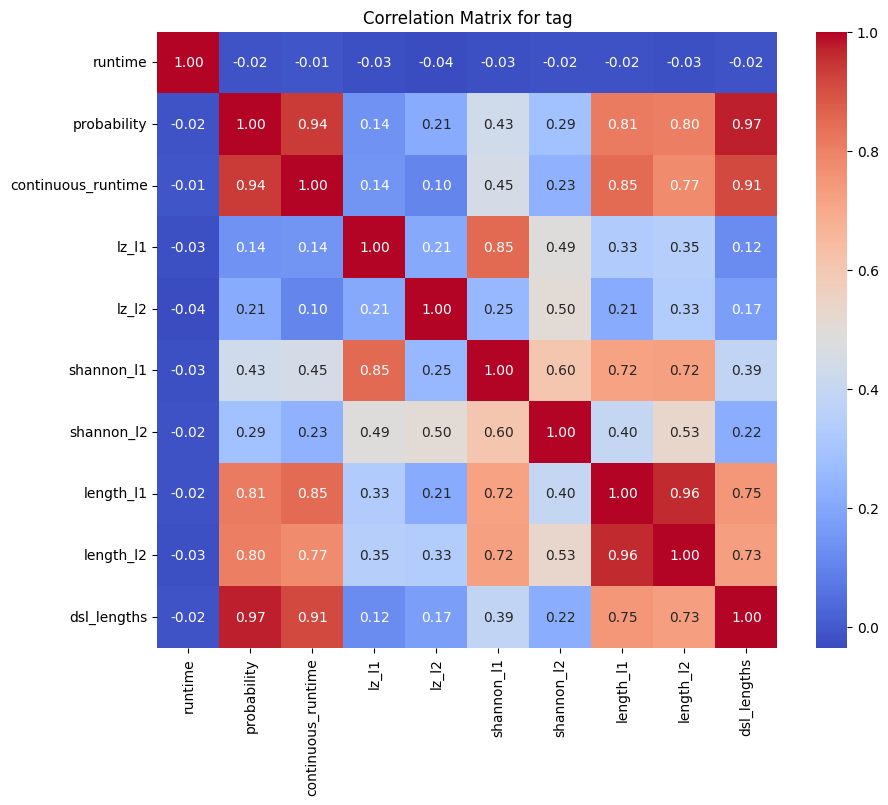

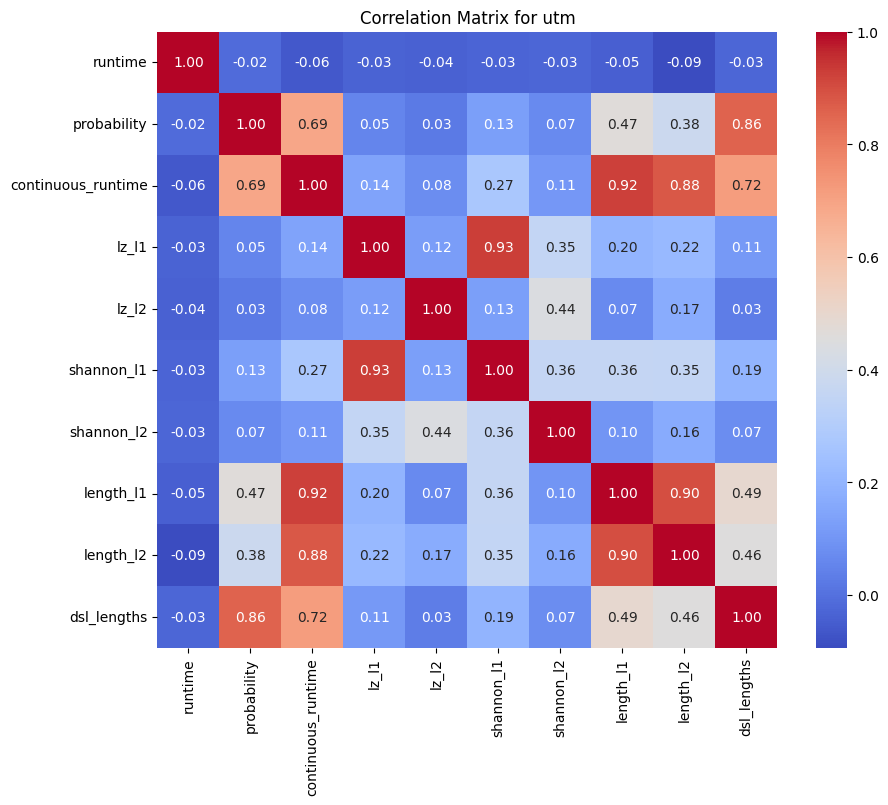

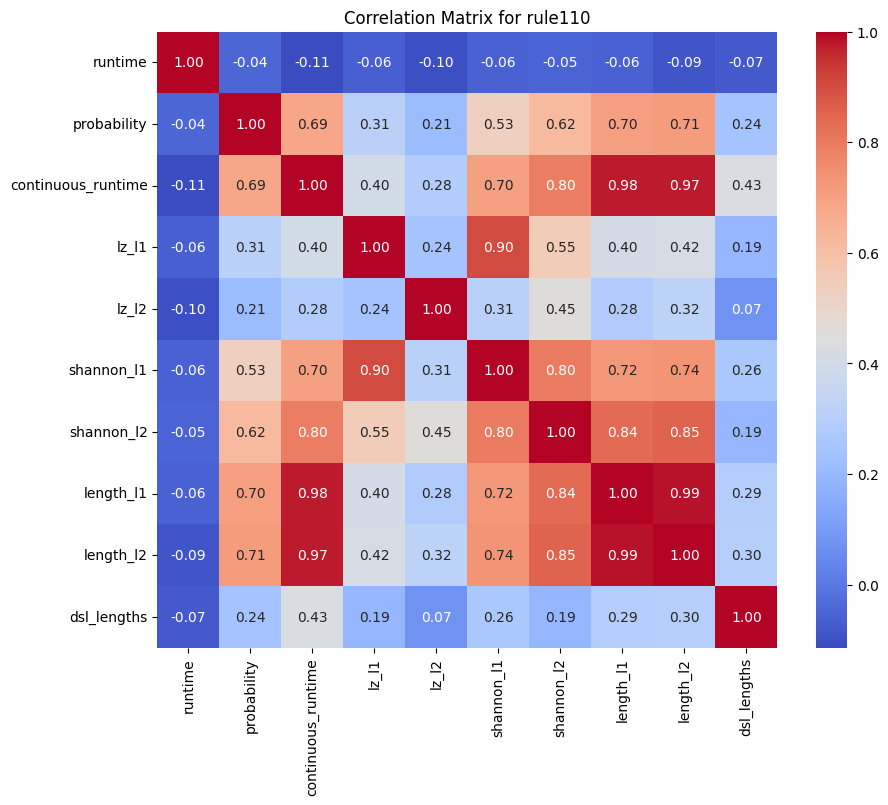

In [163]:
# measure correlation between description lengths and runtimes for each domain
correlation_results = {}
for domain, df in domain_runtimes.items():
    correlation_matrix = df.corr()
    correlation_results[domain] = correlation_matrix

# plot correlation matrices
for domain, corr_matrix in correlation_results.items():
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title(f"Correlation Matrix for {domain}")
    plt.show()

In [164]:
# add the logarithms of the description lengths and runtimes to the dataframes
for domain, df in domain_runtimes.items():
    for desc_name in ["probability", "continuous_runtime", "lz_l1", "lz_l2", "shannon_l1", "shannon_l2", "length_l1", "length_l2", "dsl_lengths"]:
        df[f"log_{desc_name}"] = np.log2(df[desc_name])

In [165]:
# for each domain, measure partial correlation between probability and description lengths, controlling for length_l1
partial_correlation_results = {}
for domain, df in domain_runtimes.items():
    partial_corr_results = {}
    for desc_name in ["log_lz_l1", "log_lz_l2", "log_shannon_l1", "log_shannon_l2", "log_dsl_lengths"]:
        pcorr = partial_corr(data=df, x=desc_name, y="log_probability", covar="log_continuous_runtime", method="pearson")
        partial_corr_results[desc_name] = pcorr
    partial_correlation_results[domain] = partial_corr_results

# print results for log_dsl_lengths
for domain, pcorr_results in partial_correlation_results.items():
    print(f"Partial correlation results for {domain}:")
    print(pcorr_results['log_dsl_lengths'])
    print()

Partial correlation results for tag:
            n         r           CI95     p_val
pearson  1883 -0.057681  [-0.1, -0.01]  0.012323

Partial correlation results for utm:
             n         r          CI95         p_val
pearson  12741  0.046985  [0.03, 0.06]  1.122370e-07

Partial correlation results for rule110:
            n        r           CI95     p_val
pearson  1637 -0.02255  [-0.07, 0.03]  0.362021



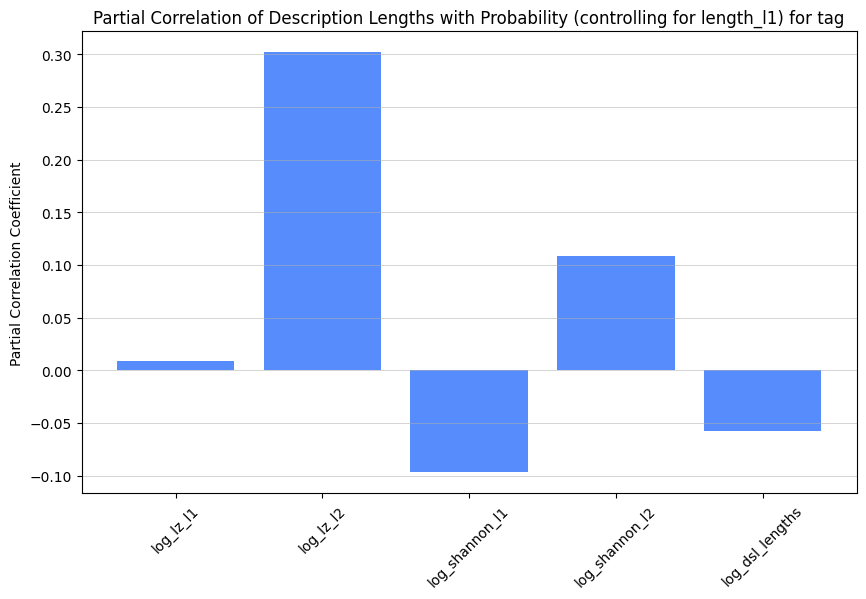

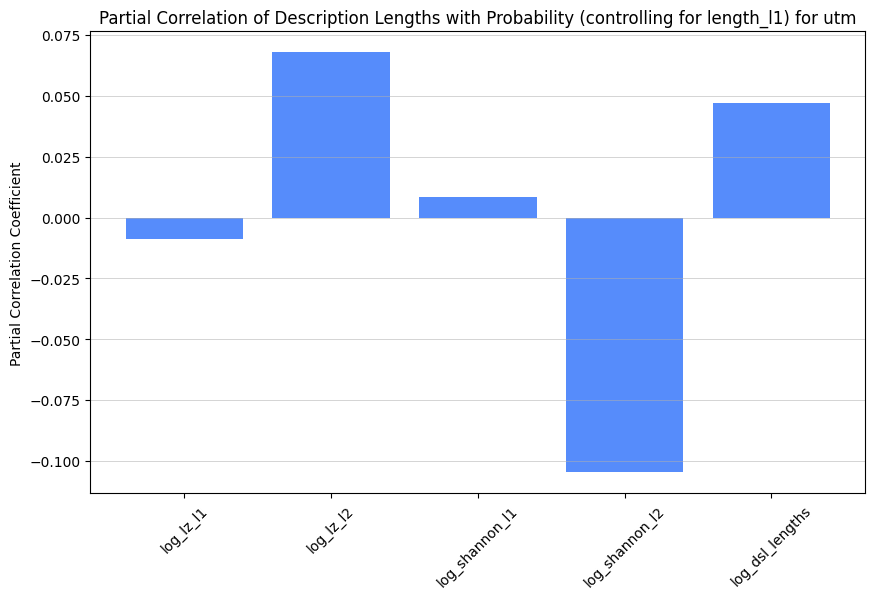

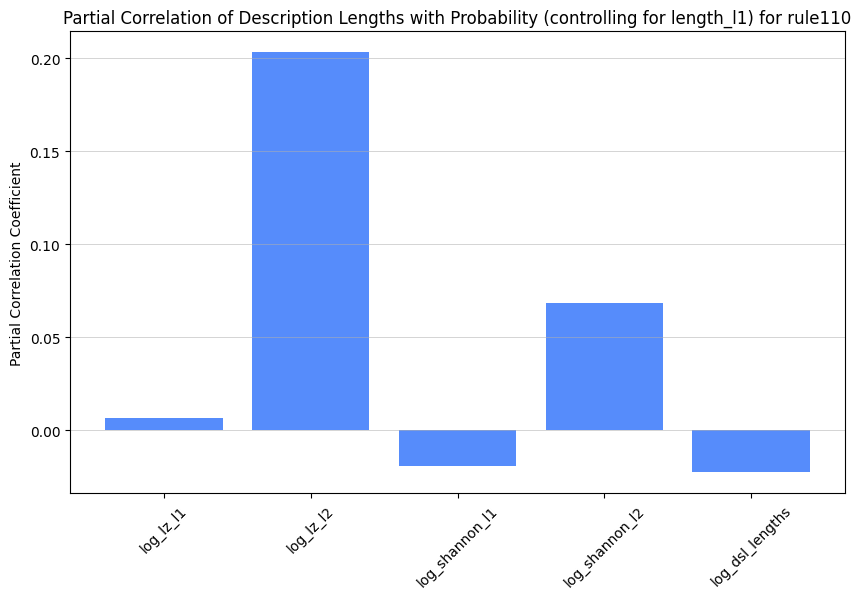

In [166]:
# plot partial correlation results
for domain, pcorr_results in partial_correlation_results.items():
    plt.figure(figsize=(10, 6))
    desc_names = list(pcorr_results.keys())
    pcorr_values = [pcorr_results[desc_name]["r"].values[0] for desc_name in desc_names]
    plt.bar(desc_names, pcorr_values)
    plt.title(f"Partial Correlation of Description Lengths with Probability (controlling for length_l1) for {domain}")
    plt.ylabel("Partial Correlation Coefficient")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.75)
plt.show()

In [176]:
domain_runtimes["tag"]["dsl_lengths"]

0       1.250000e-01
1       1.562500e-02
2       6.250000e-02
3       7.812500e-03
4       7.812500e-03
            ...     
1878    1.818989e-12
1879    1.455192e-11
1880    1.818989e-12
1881    1.164153e-10
1882    9.313226e-10
Name: dsl_lengths, Length: 1883, dtype: float64

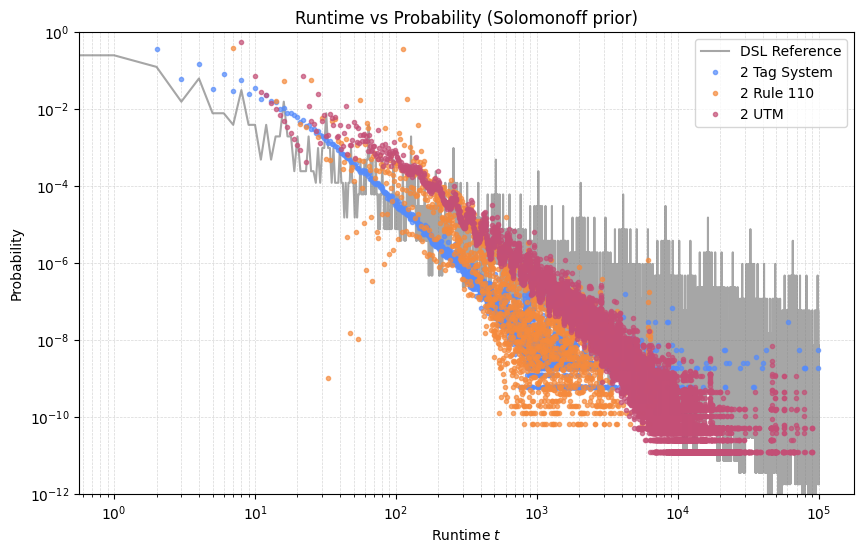

In [191]:
# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(range(len(dsl_lengths)),
           2**(-np.array(dsl_lengths).astype(float)),
           color='grey', linestyle='-', alpha=0.7, label="DSL Reference")

plt.loglog(np.array(domain_runtimes["tag"]["runtime"]),
           np.array(domain_runtimes["tag"]["probability"]),
           marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Tag System")

plt.loglog(np.array(domain_runtimes["rule110"]["runtime"]),
           np.array(domain_runtimes["rule110"]["probability"]),
           marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 Rule 110")

plt.loglog(np.array(domain_runtimes["utm"]["runtime"]),
           np.array(domain_runtimes["utm"]["probability"]),
           marker='o', linestyle='None', markersize=3, alpha=0.7, label="2 UTM")

plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.ylim(1e-12, 1e0)
# save plot as pdf
#plt.savefig("runtime_vs_probability.pdf")

plt.show()

# Correlation plots

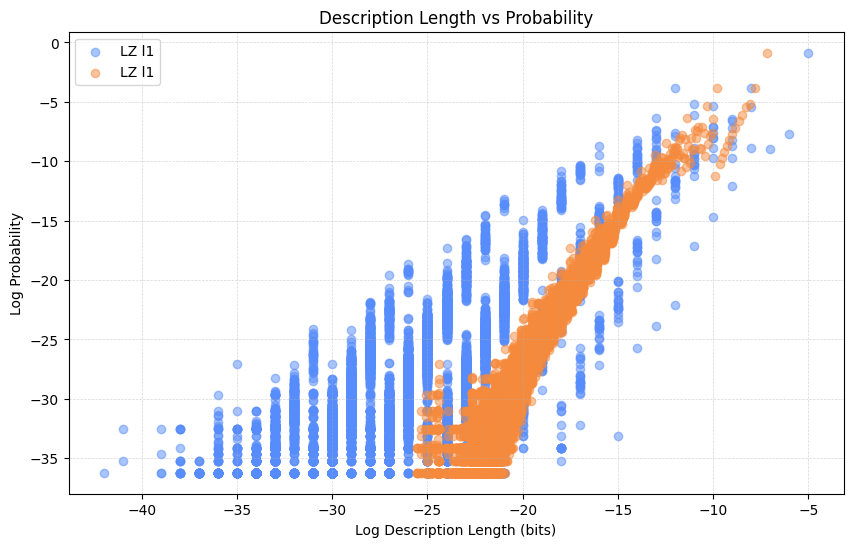

In [231]:
# for utm, plot log probabilities against log description lengths
plt.figure(figsize=(10, 6))
plt.scatter(np.log2(domain_runtimes["utm"]["dsl_lengths"]), np.log2(domain_runtimes["utm"]["probability"]), alpha=0.5, label="LZ l1")
plt.scatter(np.log2(domain_runtimes["utm"]["continuous_runtime"]), np.log2(domain_runtimes["utm"]["probability"]), alpha=0.5, label="LZ l1")

plt.title('Description Length vs Probability')
plt.xlabel('Log Description Length (bits)')
plt.ylabel('Log Probability')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [202]:
X

,const,continuous_runtime
0,1.0,-7.169925
1,1.0,-7.785970
2,1.0,-8.040502
3,1.0,-8.268879
4,1.0,-8.475833
...,...,...
12736,1.0,-25.536538
12737,1.0,-25.536670
12738,1.0,-25.536689
12739,1.0,-25.536972


In [209]:
x

array([ -7.169925  ,  -7.78596979,  -8.04050167, ..., -25.53668908,
       -25.53697206, -25.53699092])

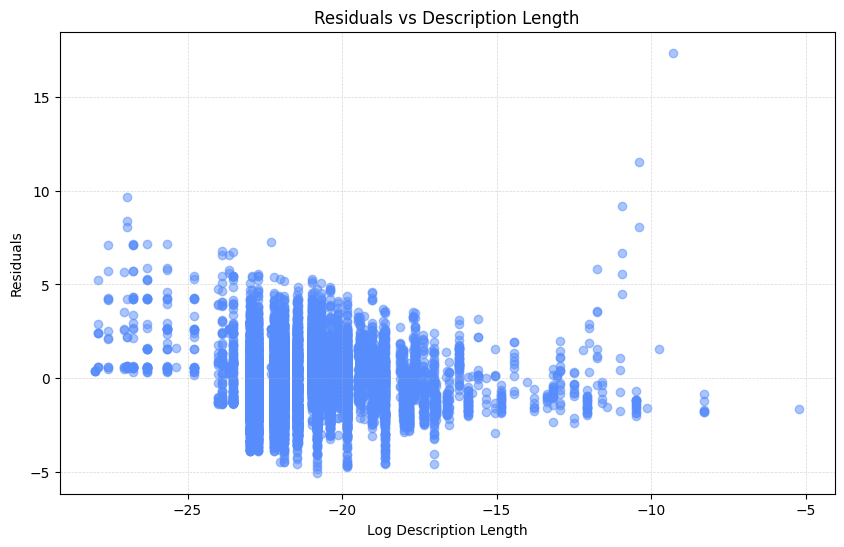

In [234]:
# control for continuous runtime by fitting a polynomial regression (3rd degree) and plotting the residuals
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

domain = "utm"

x = np.log2(domain_runtimes[domain]["continuous_runtime"]).values
y = np.log2(domain_runtimes[domain]["probability"]).values

poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x[:, None])

model = LinearRegression()
model.fit(x_poly, y)

y_pred = model.predict(x_poly)
prob_residuals = y - y_pred

dsl = np.log2(domain_runtimes[domain]["shannon_l2"]).values

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.scatter(dsl, prob_residuals, alpha=0.5)
plt.title('Residuals vs Description Length')
plt.xlabel('Log Description Length')
plt.ylabel('Residuals')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

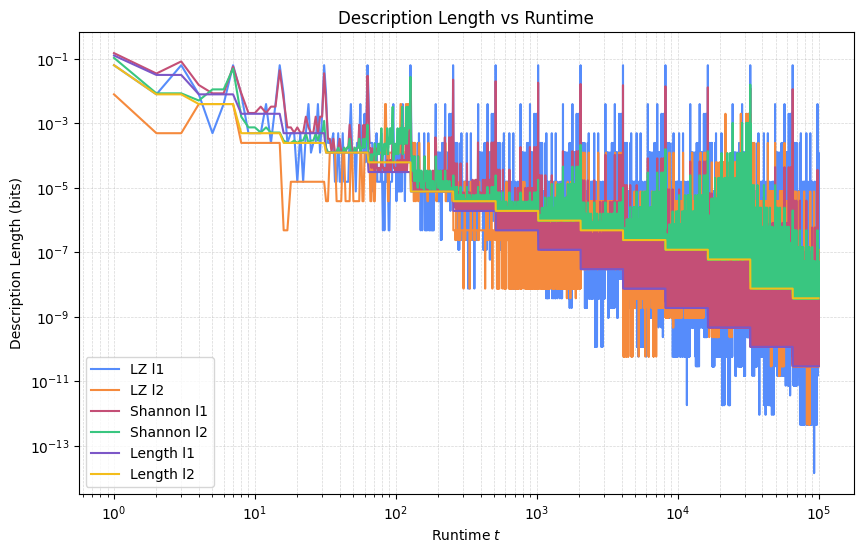

In [38]:
# plot description lengths against runtimes
plt.figure(figsize=(10, 6))

plt.loglog(x_range, 2**(-lz_lengths_l1), label='LZ l1')
plt.loglog(x_range, 2**(-lz_lengths_l2), label='LZ l2')

plt.loglog(x_range, 2**(-description_lengths_l1), label='Shannon l1')
plt.loglog(x_range, 2**(-description_lengths_l2), label='Shannon l2')
#plt.loglog(x_range, 2**(-description_lengths_l3), label='Shannon l3')


plt.loglog(x_range, 2**(-length_l1), label='Length l1')
plt.loglog(x_range, 2**(-length_l2), label='Length l2')
#plt.loglog(x_range, 2**(-length_l3), label='Length l3')

plt.title('Description Length vs Runtime')
plt.xlabel('Runtime $t$')
plt.ylabel('Description Length (bits)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

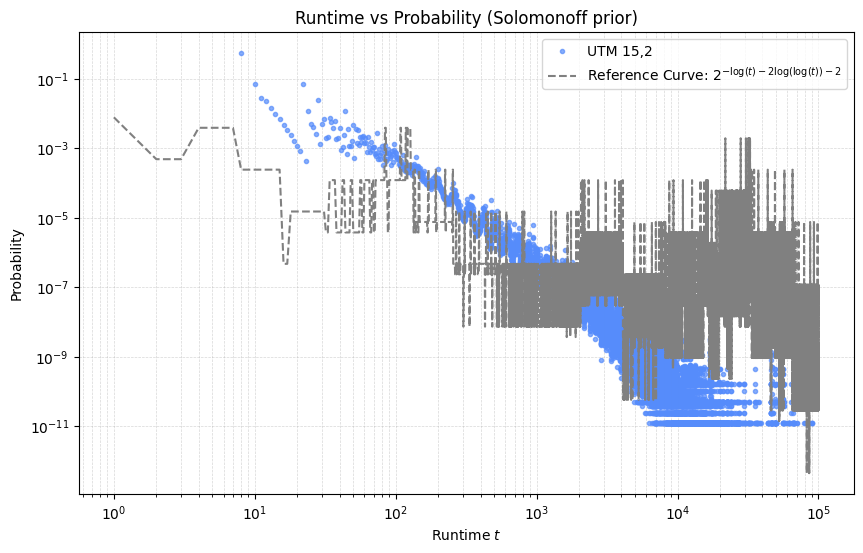

In [39]:
# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")

x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
plt.loglog(x_range, 2**(-lz_lengths_l2), color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 2}$')
plt.legend()

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [40]:
# calculate pareto front of utm_runtimes
pareto_frontier = []
current_max_prob = 0

for i in reversed(range(1, max_runtime)):
    runtime = i
    probability = utm_probabilities_weighted[i]
    if probability > current_max_prob:
        pareto_frontier.append((runtime, probability))
        current_max_prob = probability


In [90]:
print(pareto_frontier)

[(89893, 1.2557204058001822e-11), (89892, 5.199070693217879e-11), (78996, 1.0398141386435758e-10), (78995, 1.6164204474293735e-10), (78994, 4.4730585795996684e-10), (69177, 1.1621024532501497e-09), (49145, 1.2248884735401586e-09), (46336, 1.341917573879899e-09), (46335, 2.3242049065003043e-09), (46334, 2.9028408694930295e-09), (46333, 7.061402144786202e-09), (8511, 7.099073756960206e-09), (8503, 7.434915050504077e-09), (6221, 7.511859882863167e-09), (6220, 1.740866605569132e-08), (5023, 1.8774385450774957e-08), (4852, 2.1486409484263178e-08), (4848, 3.7022481198680965e-08), (3920, 3.843699998392279e-08), (3893, 5.1297889718159903e-08), (3662, 9.831028017165153e-08), (3542, 1.0192038043376437e-07), (2862, 1.053323586745055e-07), (2852, 1.2413493301100835e-07), (2841, 1.5258955149725228e-07), (2839, 2.712327775117298e-07), (1963, 3.2146508608818015e-07), (1784, 5.386339065801868e-07), (1626, 5.985395386318737e-07), (1585, 1.1854642679579466e-06), (1241, 1.534331655732806e-06), (951, 1.58

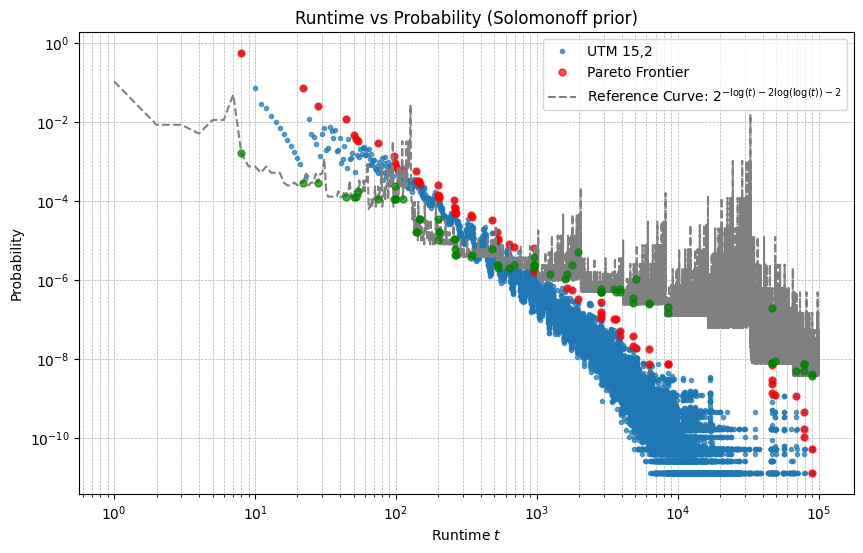

In [93]:
# log-log plot of runtimes against probability
utm_total_programs_weighted = np.sum(utm_num_runtimes_weighted)
utm_probabilities_weighted = utm_num_runtimes_weighted / utm_total_programs_weighted

# Create a log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(np.arange(max_runtime), utm_probabilities_weighted, marker='o', linestyle='None', markersize=3, alpha=0.7, label="UTM 15,2")

# pareto frontier points in red
plt.loglog(np.array([p[0] for p in pareto_frontier]), np.array([p[1] for p in pareto_frontier]), marker='o', linestyle='None', markersize=5, alpha=0.7, color='red', label="Pareto Frontier")


x_range = np.arange(1, max_runtime)
reference_curve = 1 / x_range
plt.loglog(x_range, 2**(-description_lengths), color='grey', linestyle='--', label='Reference Curve: $2^{-\log(t) - 2\log(\log(t)) - 2}$')
plt.legend()

plt.loglog(np.array([p[0] for p in pareto_frontier]), np.array([2**(-description_lengths[p[0]-1]) for p in pareto_frontier]), marker='o', linestyle='None', markersize=5, alpha=0.7, color='green', label="Pareto Frontier")

plt.title('Runtime vs Probability (Solomonoff prior)')
plt.xlabel('Runtime $t$')
plt.ylabel('Probability')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

In [38]:
print(f"average description length: {np.mean(description_lengths)}")

average description length: 27.934921069028665


In [39]:
pareto_description_lengths = np.array([description_length(binary_representation(p[0])) for p in pareto_frontier])
print(f"average description length of pareto frontier: {np.mean(pareto_description_lengths)}")

average description length of pareto frontier: 21.275058677459548
